# 01 — Exploratory Data Analysis

Full characterisation of the Sparkov dataset before any label derivation or modelling.

| Section | Focus |
|---|---|
| 1 | Dataset overview & class balance |
| 2 | Transaction amounts |
| 3 | Temporal patterns |
| 4 | Geographic patterns |
| 5 | Merchant category analysis |
| 6 | Cardholder demographics |
| 7 | Behavioral / velocity patterns |
| 8 | Numeric correlations |

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import sys
sys.path.insert(0, "..")

FRAUD   = "#DC2626"
LEGIT   = "#2563EB"
NEUTRAL = "#6B7280"
ACCENT  = "#D97706"

plt.rcParams.update({
    "figure.dpi": 130,
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.titlesize":    13,
    "axes.labelsize":    11,
    "xtick.labelsize":   9,
    "ytick.labelsize":   9,
    "legend.fontsize":   9,
})
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.4f}".format)

In [2]:
train = pd.read_csv("../data/raw/fraudTrain.csv", index_col=0,
                    parse_dates=["trans_date_trans_time", "dob"])
test  = pd.read_csv("../data/raw/fraudTest.csv",  index_col=0,
                    parse_dates=["trans_date_trans_time", "dob"])

for df in (train, test):
    df["hour"]      = df["trans_date_trans_time"].dt.hour
    df["dow"]       = df["trans_date_trans_time"].dt.day_name()
    df["month"]     = df["trans_date_trans_time"].dt.to_period("M")
    df["age"]       = (df["trans_date_trans_time"] - df["dob"]).dt.days / 365.25
    df["age_group"] = pd.cut(df["age"], bins=[0,25,35,45,55,65,100],
                             labels=["<25","25-34","35-44","45-54","55-64","65+"])
    df["log_amt"]   = np.log1p(df["amt"])

print(f"Train : {len(train):>9,} rows  |  fraud rate: {train.is_fraud.mean()*100:.3f}%")
print(f"Test  : {len(test):>9,} rows  |  fraud rate: {test.is_fraud.mean()*100:.3f}%")
print(f"Cards : {train.cc_num.nunique():,}  |  Merchants: {train.merchant.nunique():,}  |  Categories: {train.category.nunique()}")
print(f"Dates : {train.trans_date_trans_time.min().date()} to {train.trans_date_trans_time.max().date()}")
print(f"Missing values: {train.isnull().sum().sum()}")

Train : 1,296,675 rows  |  fraud rate: 0.579%
Test  :   555,719 rows  |  fraud rate: 0.386%
Cards : 983  |  Merchants: 693  |  Categories: 14
Dates : 2019-01-01 to 2020-06-21
Missing values: 0


## 1 — Class balance

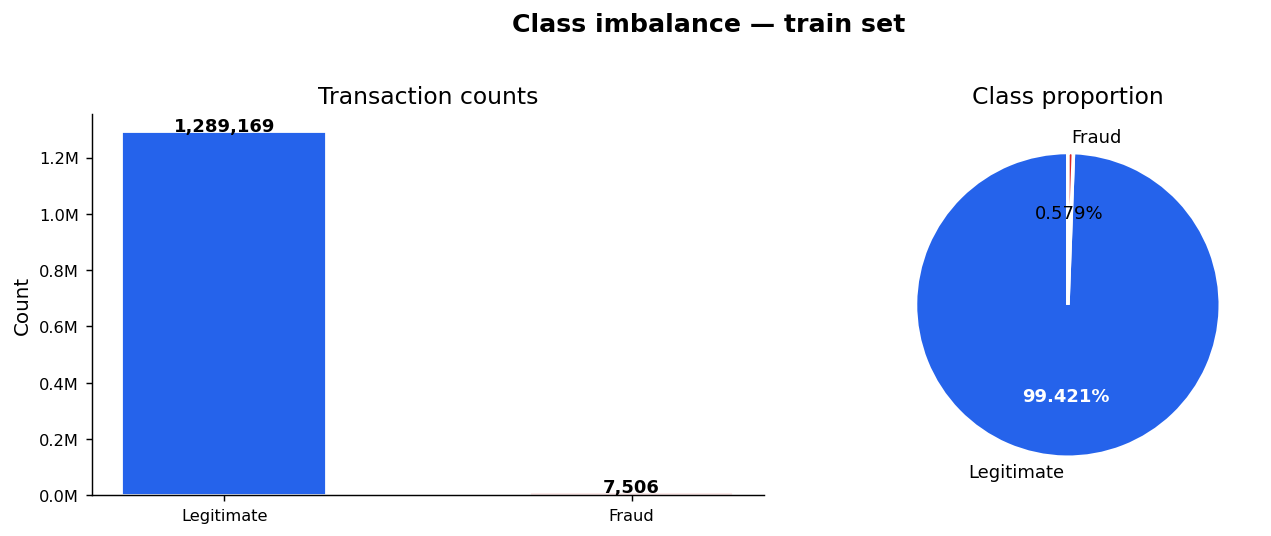

Imbalance ratio  (legit:fraud): 172:1


In [3]:
counts = train["is_fraud"].value_counts().sort_index()
labels = ["Legitimate", "Fraud"]
colors = [LEGIT, FRAUD]

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].bar(labels, counts.values, color=colors, width=0.5, edgecolor="white")
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 5000, f"{v:,}", ha="center", fontsize=10, fontweight="bold")
axes[0].set_title("Transaction counts")
axes[0].set_ylabel("Count")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))

wedges, texts, autotexts = axes[1].pie(
    counts.values, labels=labels, colors=colors,
    autopct="%1.3f%%", startangle=90,
    wedgeprops={"edgecolor": "white", "linewidth": 2},
    textprops={"fontsize": 10},
)
autotexts[0].set_color("white")
autotexts[0].set_fontweight("bold")
axes[1].set_title("Class proportion")

plt.suptitle("Class imbalance — train set", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

print(f"Imbalance ratio  (legit:fraud): {counts[0]/counts[1]:.0f}:1")

## 2 — Transaction amounts

C:\Users\asus\AppData\Local\Temp\ipykernel_18764\3795738859.py:34: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[2].boxplot(data_box, labels=["Legitimate", "Fraud"], patch_artist=True,


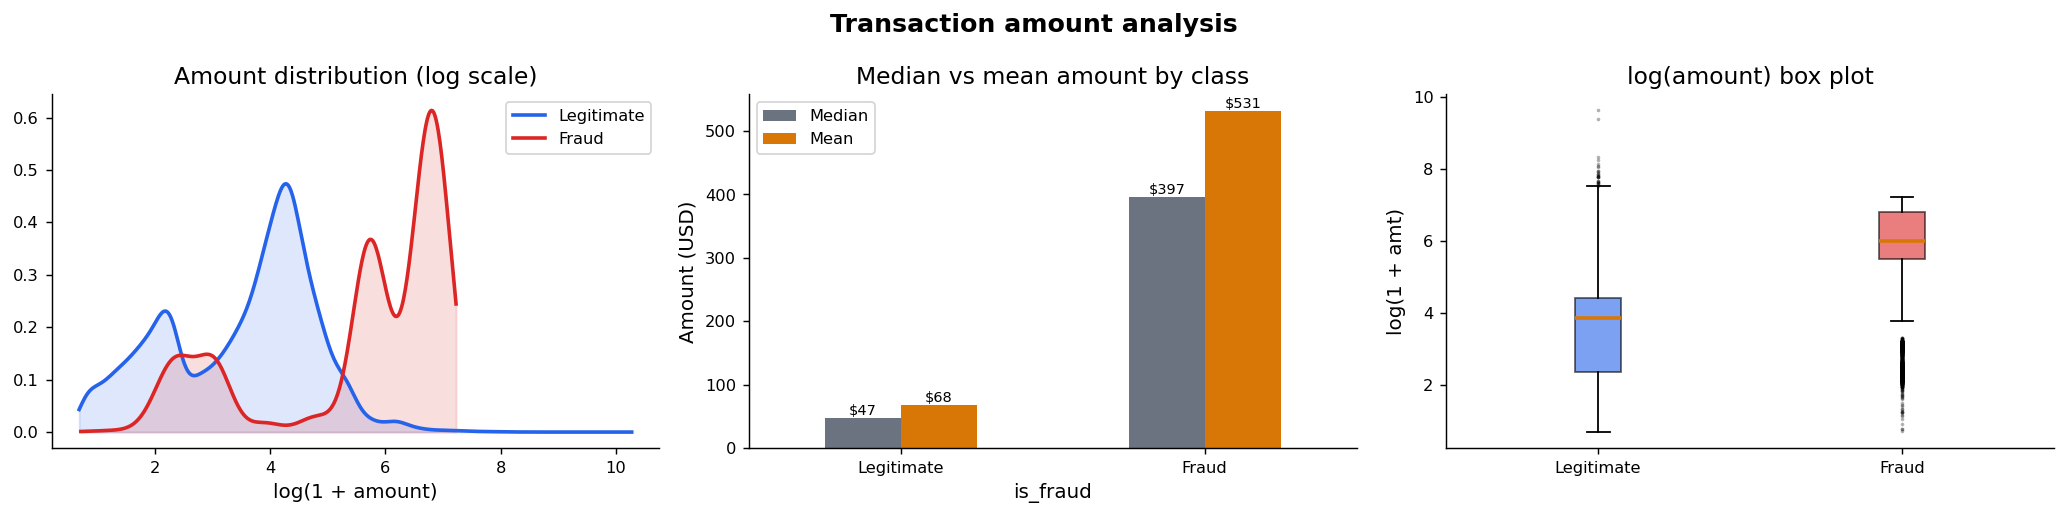

Amount summary by class:
                count     mean      std    min      25%      50%      75%  \
is_fraud                                                                    
0        1289169.0000  67.6700 154.0100 1.0000   9.6100  47.2800  82.5400   
1           7506.0000 531.3200 390.5600 1.0600 245.6600 396.5000 900.8800   

                max  
is_fraud             
0        28948.9000  
1         1376.0400  


In [4]:
fraud_amt = train.loc[train.is_fraud == 1, "amt"]
legit_amt = train.loc[train.is_fraud == 0, "amt"]

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# KDE on log scale
for vals, color, name in [(legit_amt, LEGIT, "Legitimate"), (fraud_amt, FRAUD, "Fraud")]:
    log_vals = np.log1p(vals)
    sample   = log_vals.sample(min(50_000, len(log_vals)), random_state=0)
    kde = stats.gaussian_kde(sample)
    xs  = np.linspace(log_vals.min(), log_vals.max(), 400)
    axes[0].plot(xs, kde(xs), color=color, lw=2, label=name)
    axes[0].fill_between(xs, kde(xs), alpha=0.15, color=color)
axes[0].set_xlabel("log(1 + amount)")
axes[0].set_title("Amount distribution (log scale)")
axes[0].legend()

# Median / mean bar
stats_df = (train.groupby("is_fraud")["amt"]
            .agg(["median", "mean"])
            .rename(index={0: "Legitimate", 1: "Fraud"}))
stats_df.plot(kind="bar", ax=axes[1], color=[NEUTRAL, ACCENT], rot=0, width=0.5)
axes[1].set_title("Median vs mean amount by class")
axes[1].set_ylabel("Amount (USD)")
axes[1].legend(["Median", "Mean"])
for p in axes[1].patches:
    axes[1].annotate(f"${p.get_height():.0f}",
                     (p.get_x() + p.get_width()/2, p.get_height()),
                     ha="center", va="bottom", fontsize=8)

# Boxplot
data_box = [np.log1p(legit_amt.sample(50_000, random_state=0)),
            np.log1p(fraud_amt)]
bp = axes[2].boxplot(data_box, labels=["Legitimate", "Fraud"], patch_artist=True,
                     medianprops=dict(color=ACCENT, lw=2),
                     flierprops=dict(marker=".", markersize=2, alpha=0.3))
for patch, color in zip(bp["boxes"], [LEGIT, FRAUD]):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
axes[2].set_title("log(amount) box plot")
axes[2].set_ylabel("log(1 + amt)")

plt.suptitle("Transaction amount analysis", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

print("Amount summary by class:")
print(train.groupby("is_fraud")["amt"].describe().round(2))

## 3 — Temporal patterns

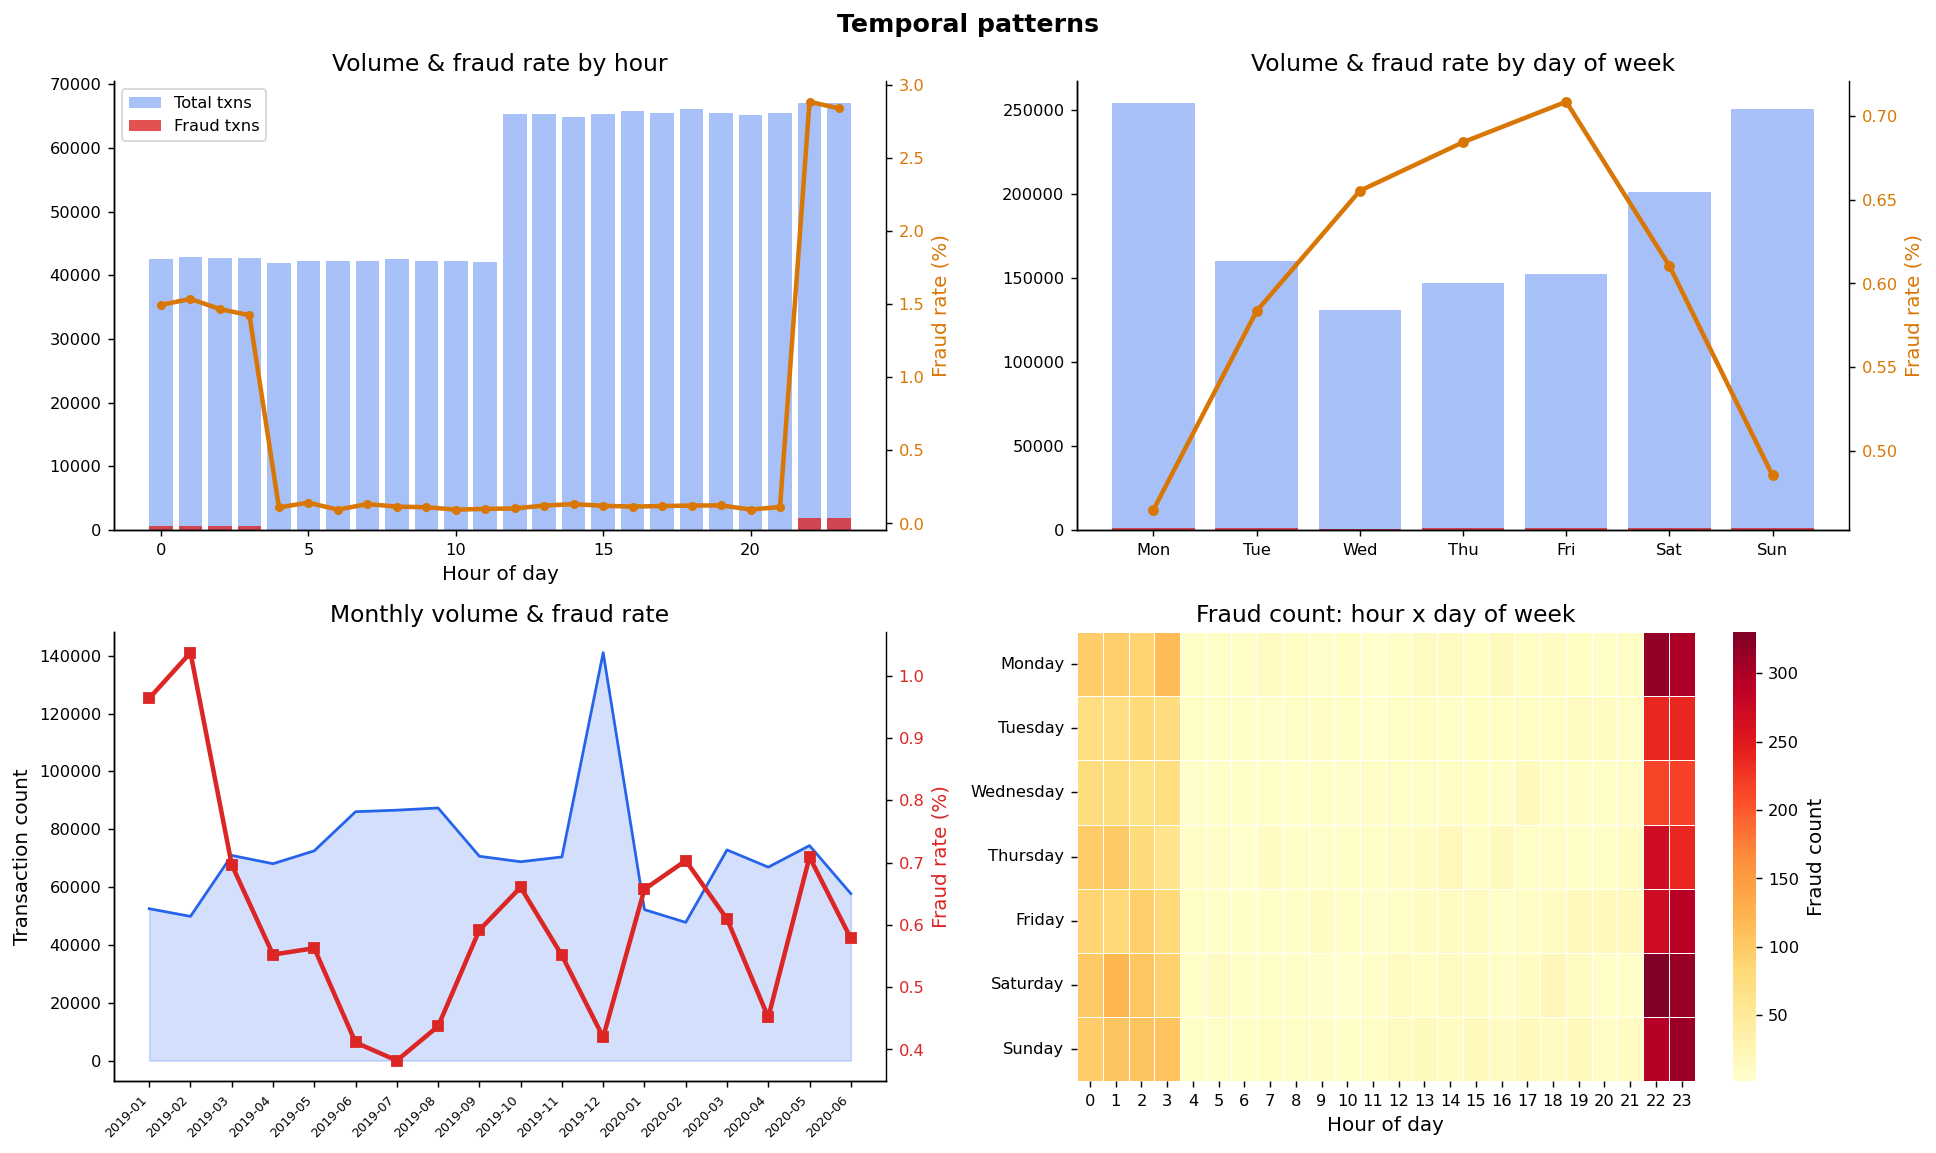

In [5]:
DOW_ORDER = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]

fig, axes = plt.subplots(2, 2, figsize=(15, 9))

# 3a: Volume & fraud rate by hour
hourly = (train.groupby("hour")["is_fraud"]
          .agg(fraud="sum", total="count")
          .assign(rate=lambda d: d["fraud"] / d["total"] * 100))
ax, ax2 = axes[0, 0], axes[0, 0].twinx()
ax.bar(hourly.index, hourly["total"], color=LEGIT, alpha=0.4, label="Total txns")
ax.bar(hourly.index, hourly["fraud"],  color=FRAUD, alpha=0.8, label="Fraud txns")
ax2.plot(hourly.index, hourly["rate"], color=ACCENT, lw=2.5, marker="o", markersize=4)
ax.set_xlabel("Hour of day")
ax.set_title("Volume & fraud rate by hour")
ax.legend(loc="upper left")
ax2.set_ylabel("Fraud rate (%)", color=ACCENT)
ax2.tick_params(axis="y", labelcolor=ACCENT)
ax2.spines["right"].set_visible(True)

# 3b: Volume & fraud rate by day of week
daily_dow = (train.groupby("dow")["is_fraud"]
             .agg(fraud="sum", total="count")
             .reindex(DOW_ORDER)
             .assign(rate=lambda d: d["fraud"] / d["total"] * 100))
ax, ax2 = axes[0, 1], axes[0, 1].twinx()
ax.bar(range(7), daily_dow["total"], color=LEGIT, alpha=0.4)
ax.bar(range(7), daily_dow["fraud"],  color=FRAUD, alpha=0.8)
ax2.plot(range(7), daily_dow["rate"], color=ACCENT, lw=2.5, marker="o", markersize=5)
ax.set_xticks(range(7))
ax.set_xticklabels([d[:3] for d in DOW_ORDER])
ax.set_title("Volume & fraud rate by day of week")
ax2.set_ylabel("Fraud rate (%)", color=ACCENT)
ax2.tick_params(axis="y", labelcolor=ACCENT)
ax2.spines["right"].set_visible(True)

# 3c: Monthly fraud rate trend
monthly = (train.groupby("month")["is_fraud"]
           .agg(fraud="sum", total="count")
           .assign(rate=lambda d: d["fraud"] / d["total"] * 100))
months_str = [str(m) for m in monthly.index]
ax, ax2 = axes[1, 0], axes[1, 0].twinx()
ax.fill_between(range(len(monthly)), monthly["total"].values, alpha=0.2, color=LEGIT)
ax.plot(range(len(monthly)), monthly["total"].values, color=LEGIT, lw=1.5)
ax2.plot(range(len(monthly)), monthly["rate"].values,
         color=FRAUD, lw=2.5, marker="s", markersize=5)
ax.set_xticks(range(len(monthly)))
ax.set_xticklabels(months_str, rotation=45, ha="right", fontsize=7)
ax.set_title("Monthly volume & fraud rate")
ax.set_ylabel("Transaction count")
ax2.set_ylabel("Fraud rate (%)", color=FRAUD)
ax2.tick_params(axis="y", labelcolor=FRAUD)
ax2.spines["right"].set_visible(True)

# 3d: Fraud count heatmap hour x dow
heatmap_data = (
    train[train.is_fraud == 1]
    .groupby(["dow", "hour"]).size()
    .unstack(fill_value=0)
    .reindex(DOW_ORDER)
)
sns.heatmap(heatmap_data, ax=axes[1, 1], cmap="YlOrRd",
            linewidths=0.3, linecolor="white",
            cbar_kws={"label": "Fraud count"})
axes[1, 1].set_title("Fraud count: hour x day of week")
axes[1, 1].set_xlabel("Hour of day")
axes[1, 1].set_ylabel("")

plt.suptitle("Temporal patterns", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

## 4 — Geographic patterns

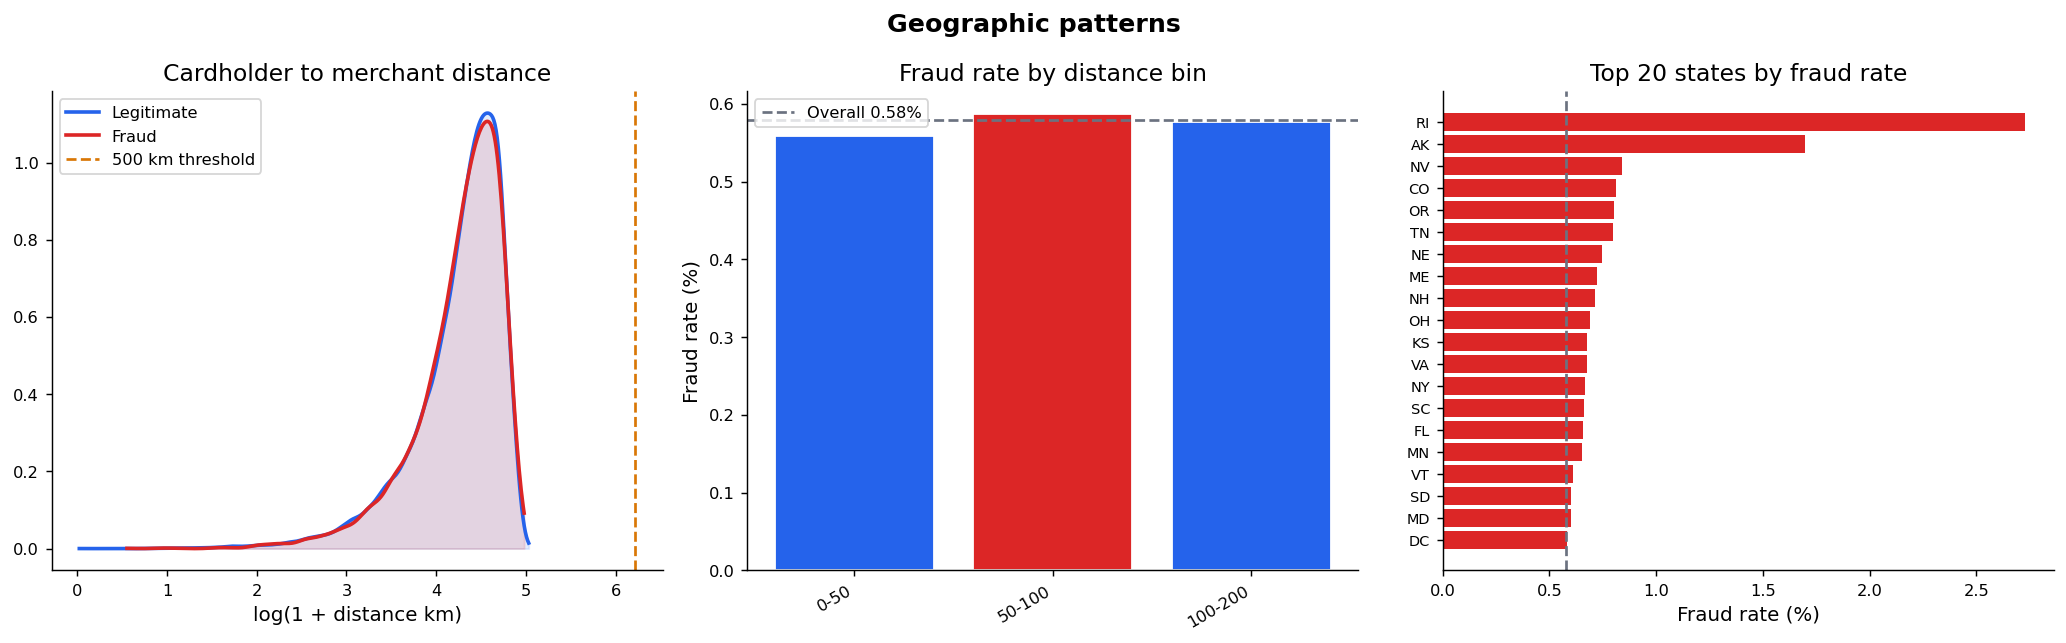

Transactions > 500 km : 0.00%
Fraud rate > 500 km   : nan%
Fraud rate <= 500 km  : 0.579%


In [6]:
from src.labels import _haversine_series

train["dist_km"] = _haversine_series(
    train["lat"], train["long"], train["merch_lat"], train["merch_long"]
)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 4a: Distance KDE fraud vs legit
for label, color, name in [(0, LEGIT, "Legitimate"), (1, FRAUD, "Fraud")]:
    d = np.log1p(train.loc[train.is_fraud == label, "dist_km"])
    sample = d.sample(min(50_000, len(d)), random_state=42)
    kde = stats.gaussian_kde(sample)
    xs  = np.linspace(d.min(), d.max(), 400)
    axes[0].plot(xs, kde(xs), color=color, lw=2, label=name)
    axes[0].fill_between(xs, kde(xs), alpha=0.12, color=color)
axes[0].axvline(np.log1p(500), color=ACCENT, lw=1.5, linestyle="--", label="500 km threshold")
axes[0].set_xlabel("log(1 + distance km)")
axes[0].set_title("Cardholder to merchant distance")
axes[0].legend()

# 4b: Fraud rate by distance bin
dist_bins   = [0, 50, 100, 200, 500, 1000, 5000, 25000]
dist_labels = ["0-50","50-100","100-200","200-500","500-1k","1k-5k","5k+"]
train["dist_bin"] = pd.cut(train["dist_km"], bins=dist_bins, labels=dist_labels)
dist_stats = (train.groupby("dist_bin", observed=True)["is_fraud"]
              .agg(["mean", "count"]))
bar_colors = [FRAUD if r > train.is_fraud.mean() else LEGIT for r in dist_stats["mean"]]
axes[1].bar(range(len(dist_stats)), dist_stats["mean"] * 100,
            color=bar_colors, edgecolor="white")
axes[1].axhline(train.is_fraud.mean() * 100, color=NEUTRAL, lw=1.5,
                linestyle="--", label=f"Overall {train.is_fraud.mean()*100:.2f}%")
axes[1].set_xticks(range(len(dist_stats)))
axes[1].set_xticklabels(dist_stats.index, rotation=30, ha="right")
axes[1].set_ylabel("Fraud rate (%)")
axes[1].set_title("Fraud rate by distance bin")
axes[1].legend()

# 4c: Top 20 states by fraud rate
state_stats = (
    train.groupby("state")["is_fraud"]
    .agg(["mean", "count"])
    .query("count >= 500")
    .sort_values("mean", ascending=True)
    .tail(20)
)
state_colors = [FRAUD if r > train.is_fraud.mean() else LEGIT for r in state_stats["mean"]]
axes[2].barh(range(len(state_stats)), state_stats["mean"] * 100,
             color=state_colors)
axes[2].axvline(train.is_fraud.mean() * 100, color=NEUTRAL, lw=1.5, linestyle="--")
axes[2].set_yticks(range(len(state_stats)))
axes[2].set_yticklabels(state_stats.index, fontsize=8)
axes[2].set_xlabel("Fraud rate (%)")
axes[2].set_title("Top 20 states by fraud rate")

plt.suptitle("Geographic patterns", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

print(f"Transactions > 500 km : {(train.dist_km > 500).mean()*100:.2f}%")
print(f"Fraud rate > 500 km   : {train.loc[train.dist_km > 500, 'is_fraud'].mean()*100:.3f}%")
print(f"Fraud rate <= 500 km  : {train.loc[train.dist_km <= 500, 'is_fraud'].mean()*100:.3f}%")

## 5 — Merchant category analysis

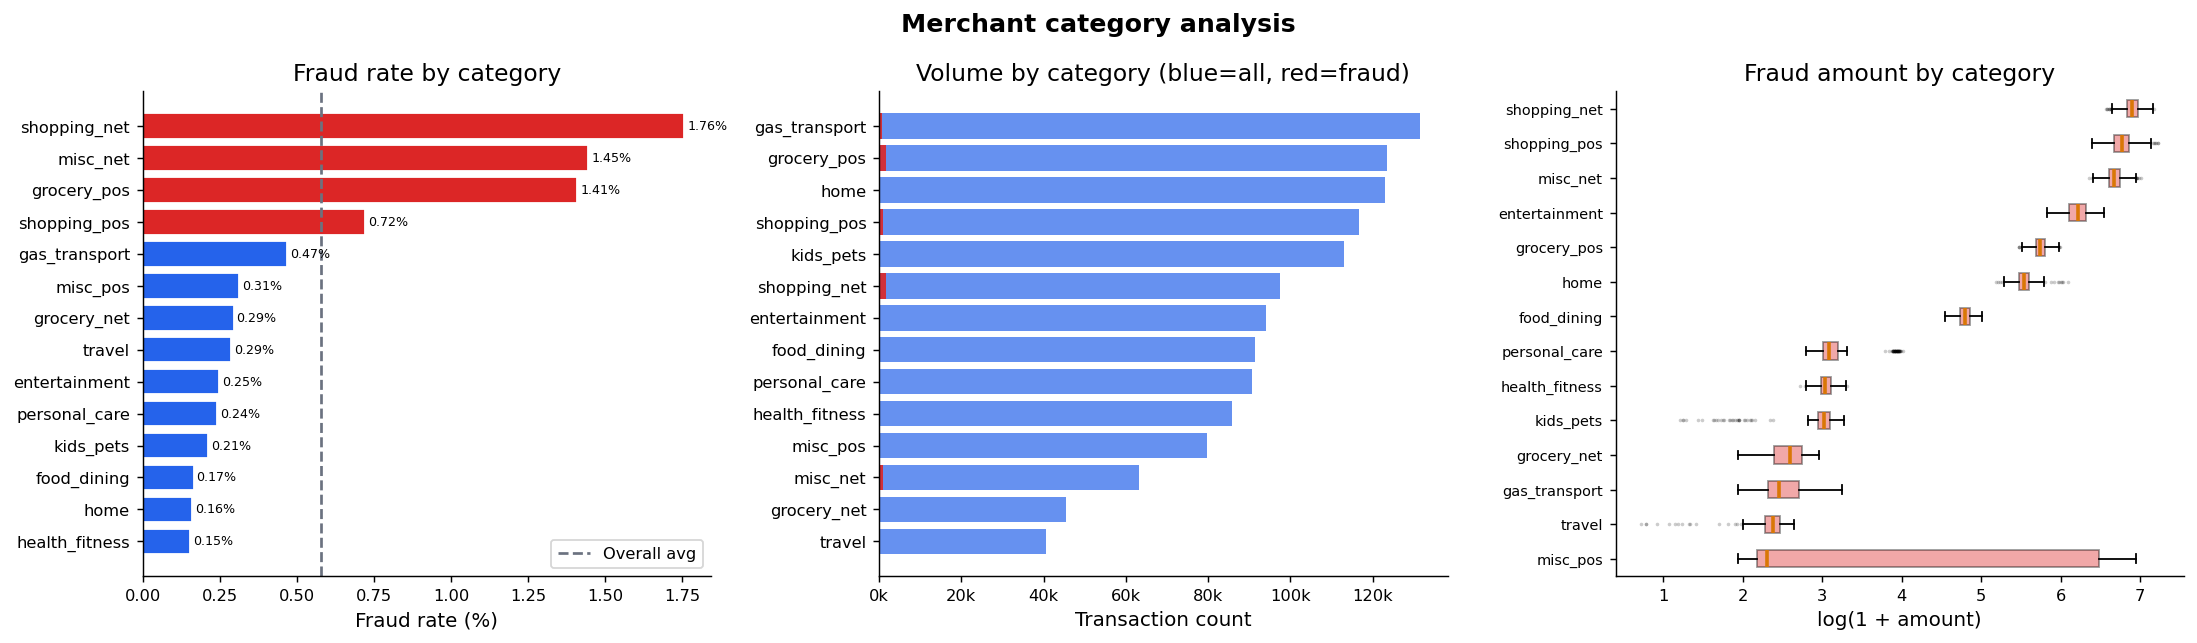

Top 5 categories by fraud rate:
               fraud_rate  fraud_count   total
category                                      
shopping_net       0.0176         1713   97543
misc_net           0.0145          915   63287
grocery_pos        0.0141         1743  123638
shopping_pos       0.0072          843  116672
gas_transport      0.0047          618  131659


In [7]:
cat_stats = (
    train.groupby("category")["is_fraud"]
    .agg(fraud_rate="mean", fraud_count="sum", total="count")
    .sort_values("fraud_rate")
)

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# 5a: Fraud rate by category
cat_colors = [FRAUD if r > train.is_fraud.mean() else LEGIT for r in cat_stats["fraud_rate"]]
bars = axes[0].barh(range(len(cat_stats)), cat_stats["fraud_rate"] * 100,
                    color=cat_colors, edgecolor="white")
axes[0].axvline(train.is_fraud.mean() * 100, color=NEUTRAL, lw=1.5,
                linestyle="--", label="Overall avg")
axes[0].set_yticks(range(len(cat_stats)))
axes[0].set_yticklabels(cat_stats.index, fontsize=9)
axes[0].set_xlabel("Fraud rate (%)")
axes[0].set_title("Fraud rate by category")
axes[0].legend()
for bar, val in zip(bars, cat_stats["fraud_rate"]):
    axes[0].text(val * 100 + 0.01, bar.get_y() + bar.get_height() / 2,
                 f"{val*100:.2f}%", va="center", fontsize=7)

# 5b: Volume by category
vol = cat_stats.sort_values("total")
axes[1].barh(range(len(vol)), vol["total"], color=LEGIT, alpha=0.7)
axes[1].barh(range(len(vol)), vol["fraud_count"], color=FRAUD, alpha=0.9)
axes[1].set_yticks(range(len(vol)))
axes[1].set_yticklabels(vol.index, fontsize=9)
axes[1].set_xlabel("Transaction count")
axes[1].set_title("Volume by category (blue=all, red=fraud)")
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e3:.0f}k"))

# 5c: Fraud amount boxplot by category
fraud_only = train[train.is_fraud == 1].copy()
cat_order  = fraud_only.groupby("category")["amt"].median().sort_values().index.tolist()
box_data   = [fraud_only.loc[fraud_only.category == c, "log_amt"].values for c in cat_order]
bp = axes[2].boxplot(box_data, vert=False, patch_artist=True,
                     medianprops=dict(color=ACCENT, lw=2),
                     flierprops=dict(marker=".", markersize=2, alpha=0.2, color=FRAUD))
for patch in bp["boxes"]:
    patch.set_facecolor(FRAUD)
    patch.set_alpha(0.4)
axes[2].set_yticks(range(1, len(cat_order) + 1))
axes[2].set_yticklabels(cat_order, fontsize=8)
axes[2].set_xlabel("log(1 + amount)")
axes[2].set_title("Fraud amount by category")

plt.suptitle("Merchant category analysis", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

print("Top 5 categories by fraud rate:")
print(cat_stats.sort_values("fraud_rate", ascending=False)
      [["fraud_rate", "fraud_count", "total"]].head().round(4))

## 6 — Cardholder demographics

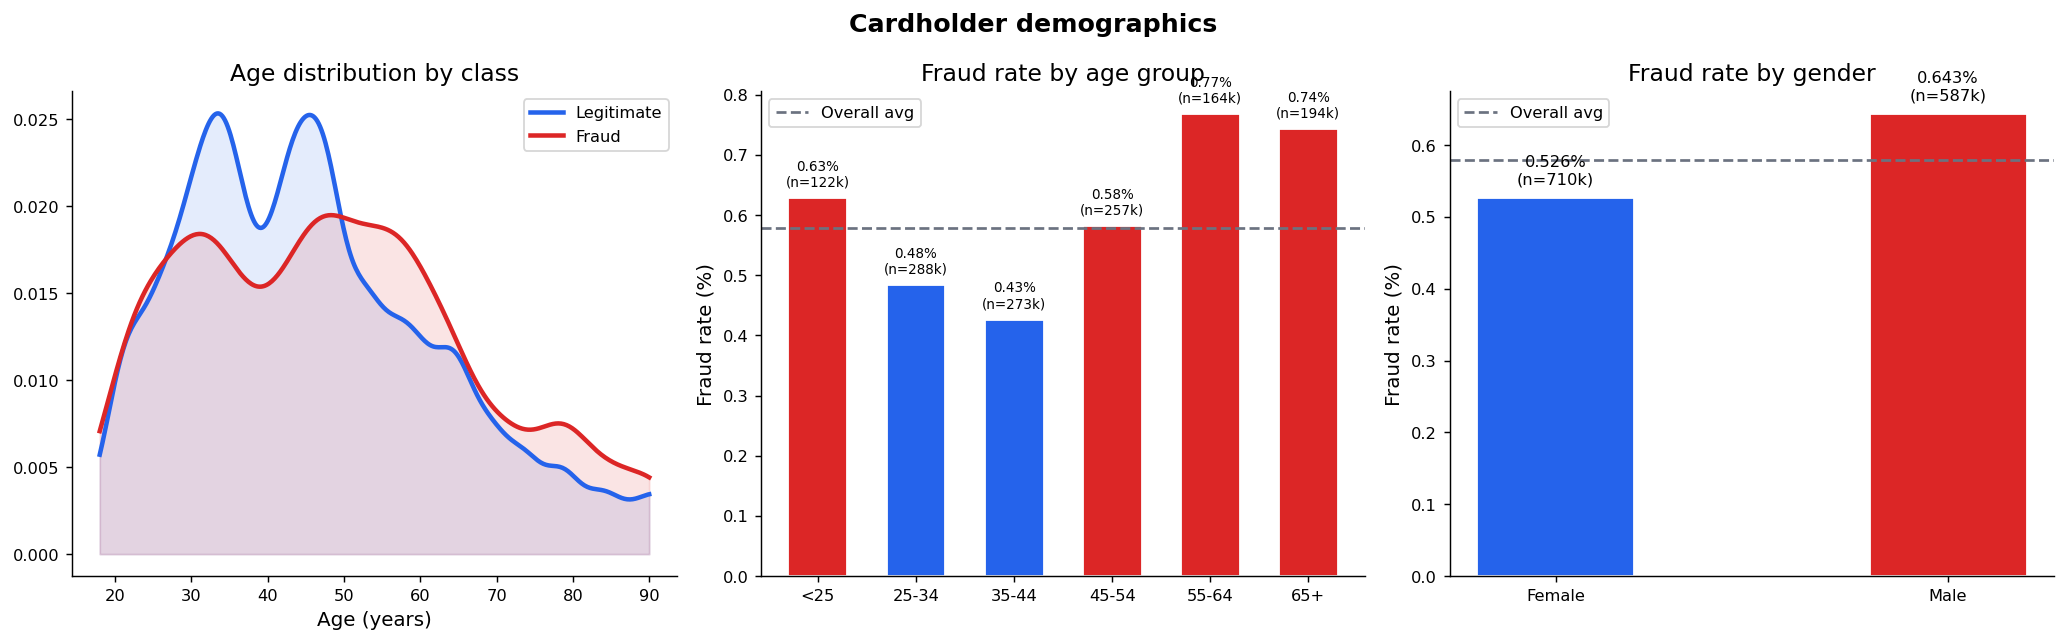


Top 15 jobs by fraud transaction count:
                                       fraud_count  fraud_rate_%
job                                                             
Materials engineer                              62        0.7500
Trading standards officer                       56        1.2070
Naval architect                                 53        0.6100
Exhibition designer                             51        0.5540
Surveyor, land/geomatics                        50        0.5760
Mechanical engineer                             49        0.8700
Prison officer                                  48        0.8420
Quantity surveyor                               48        0.8500
Audiological scientist                          46        0.7520
Senior tax professional/tax inspector           45        1.0960
Copywriter, advertising                         45        0.6300
Scientist, biomedical                           44        1.0650
Film/video editor                               4

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 6a: Age KDE
for label, color, name in [(0, LEGIT, "Legitimate"), (1, FRAUD, "Fraud")]:
    d = train.loc[train.is_fraud == label, "age"].dropna()
    kde = stats.gaussian_kde(d.sample(min(50_000, len(d)), random_state=0))
    xs  = np.linspace(18, 90, 400)
    axes[0].plot(xs, kde(xs), color=color, lw=2.5, label=name)
    axes[0].fill_between(xs, kde(xs), alpha=0.12, color=color)
axes[0].set_xlabel("Age (years)")
axes[0].set_title("Age distribution by class")
axes[0].legend()

# 6b: Fraud rate by age group
age_stats = (
    train.groupby("age_group", observed=True)["is_fraud"]
    .agg(["mean", "count"])
)
bar_colors = [FRAUD if r > train.is_fraud.mean() else LEGIT for r in age_stats["mean"]]
axes[1].bar(range(len(age_stats)), age_stats["mean"] * 100,
            color=bar_colors, edgecolor="white", width=0.6)
axes[1].axhline(train.is_fraud.mean() * 100, color=NEUTRAL, lw=1.5,
                linestyle="--", label="Overall avg")
axes[1].set_xticks(range(len(age_stats)))
axes[1].set_xticklabels(age_stats.index)
axes[1].set_ylabel("Fraud rate (%)")
axes[1].set_title("Fraud rate by age group")
axes[1].legend()
for i, (r, n) in enumerate(zip(age_stats["mean"], age_stats["count"])):
    axes[1].text(i, r * 100 + 0.02, f"{r*100:.2f}%\n(n={n/1e3:.0f}k)",
                 ha="center", fontsize=7.5)

# 6c: Fraud rate by gender
gender_stats = (train.groupby("gender")["is_fraud"]
                .agg(["mean", "count"])
                .rename(index={"M": "Male", "F": "Female"}))
axes[2].bar(gender_stats.index, gender_stats["mean"] * 100,
            color=[LEGIT, FRAUD], width=0.4, edgecolor="white")
axes[2].axhline(train.is_fraud.mean() * 100, color=NEUTRAL, lw=1.5,
                linestyle="--", label="Overall avg")
axes[2].set_ylabel("Fraud rate (%)")
axes[2].set_title("Fraud rate by gender")
axes[2].legend()
for i, (_, row) in enumerate(gender_stats.iterrows()):
    axes[2].text(i, row["mean"] * 100 + 0.02,
                 f"{row['mean']*100:.3f}%\n(n={row['count']/1e3:.0f}k)",
                 ha="center", fontsize=9)

plt.suptitle("Cardholder demographics", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

print("\nTop 15 jobs by fraud transaction count:")
job_fraud = (train[train.is_fraud == 1]["job"]
             .value_counts().head(15).to_frame("fraud_count"))
job_fraud["fraud_rate_%"] = (
    train.groupby("job")["is_fraud"].mean().reindex(job_fraud.index) * 100
)
print(job_fraud.round(3))

## 7 — Behavioral & velocity patterns

Per-card stats:   0%|          | 0/983 [00:00<?, ?card/s]

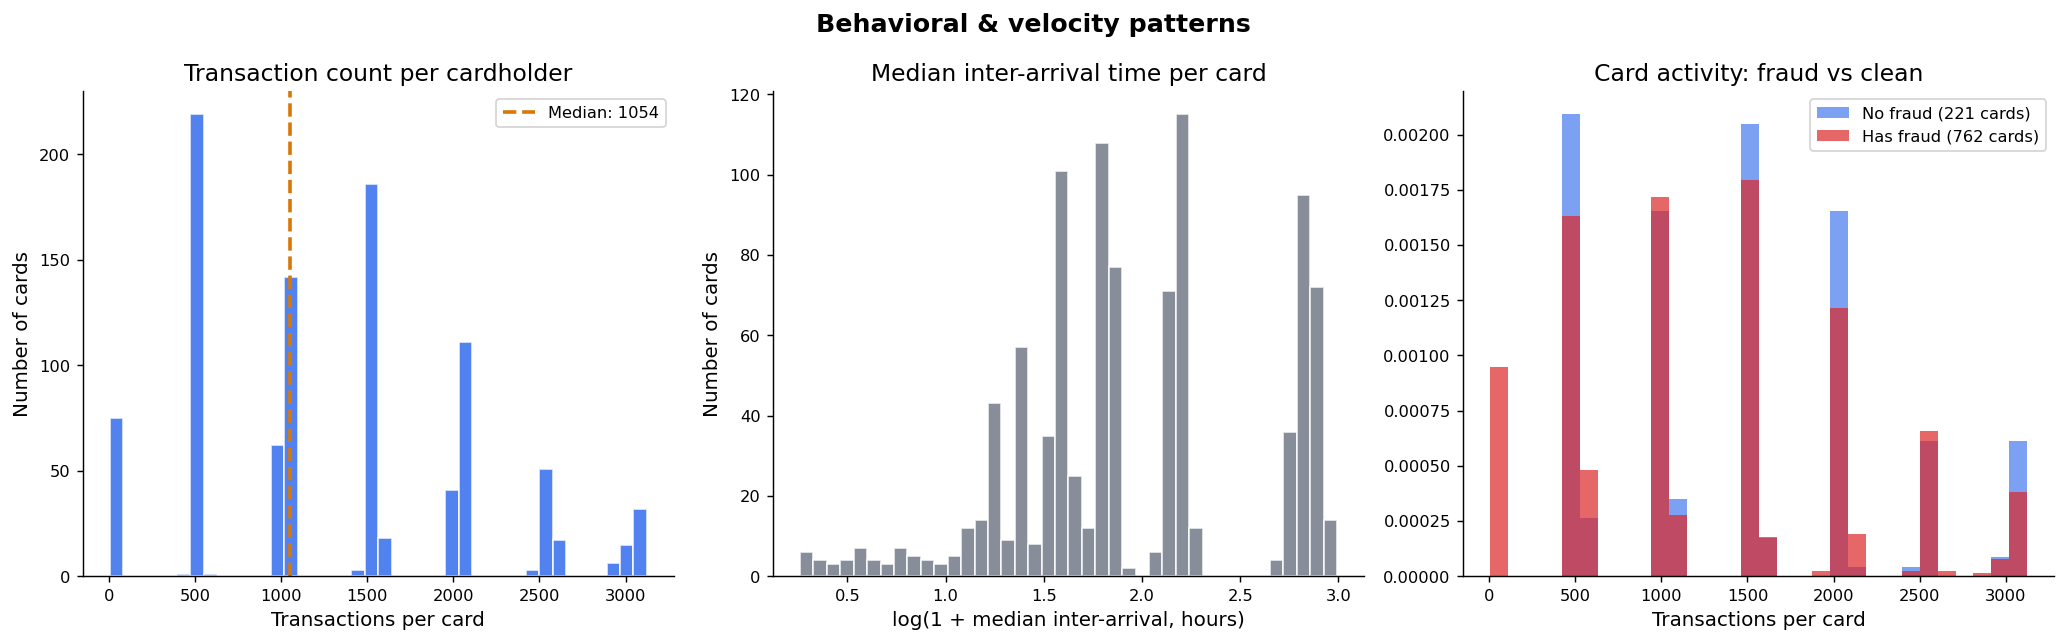

Cards with >=1 fraud txn : 762 / 983 (77.5%)
Median txns/card         : 1054
Median inter-arrival     : 5.3 hours


In [9]:
from tqdm.notebook import tqdm as tqdm_nb

card_stats = []
for cc, g in tqdm_nb(train.groupby("cc_num"), desc="Per-card stats", unit="card"):
    g_s   = g.sort_values("trans_date_trans_time")
    diffs = g_s["trans_date_trans_time"].diff().dt.total_seconds().dropna()
    card_stats.append({
        "cc_num":       cc,
        "txn_count":    len(g),
        "fraud_count":  g["is_fraud"].sum(),
        "median_iat_s": diffs.median() if len(diffs) else np.nan,
    })
card_df = pd.DataFrame(card_stats)
card_df["has_fraud"] = card_df["fraud_count"] > 0

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 7a: Transactions per card
axes[0].hist(card_df["txn_count"], bins=40, color=LEGIT, edgecolor="white", alpha=0.8)
axes[0].axvline(card_df["txn_count"].median(), color=ACCENT, lw=2, linestyle="--",
                label=f"Median: {card_df['txn_count'].median():.0f}")
axes[0].set_xlabel("Transactions per card")
axes[0].set_ylabel("Number of cards")
axes[0].set_title("Transaction count per cardholder")
axes[0].legend()

# 7b: Median inter-arrival time
iat_hrs = card_df["median_iat_s"].dropna() / 3600
axes[1].hist(np.log1p(iat_hrs), bins=40, color=NEUTRAL, edgecolor="white", alpha=0.8)
axes[1].set_xlabel("log(1 + median inter-arrival, hours)")
axes[1].set_title("Median inter-arrival time per card")
axes[1].set_ylabel("Number of cards")

# 7c: Fraud vs clean card activity
bin_edges = np.histogram_bin_edges(card_df["txn_count"], bins=30)
axes[2].hist(card_df.loc[~card_df.has_fraud, "txn_count"], bins=bin_edges,
             color=LEGIT, alpha=0.6, density=True,
             label=f"No fraud ({(~card_df.has_fraud).sum()} cards)")
axes[2].hist(card_df.loc[card_df.has_fraud, "txn_count"], bins=bin_edges,
             color=FRAUD, alpha=0.7, density=True,
             label=f"Has fraud ({card_df.has_fraud.sum()} cards)")
axes[2].set_xlabel("Transactions per card")
axes[2].set_title("Card activity: fraud vs clean")
axes[2].legend()

plt.suptitle("Behavioral & velocity patterns", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

print(f"Cards with >=1 fraud txn : {card_df.has_fraud.sum()} / {len(card_df)} ({card_df.has_fraud.mean()*100:.1f}%)")
print(f"Median txns/card         : {card_df.txn_count.median():.0f}")
print(f"Median inter-arrival     : {card_df.median_iat_s.median()/3600:.1f} hours")

## 8 — Numeric correlations

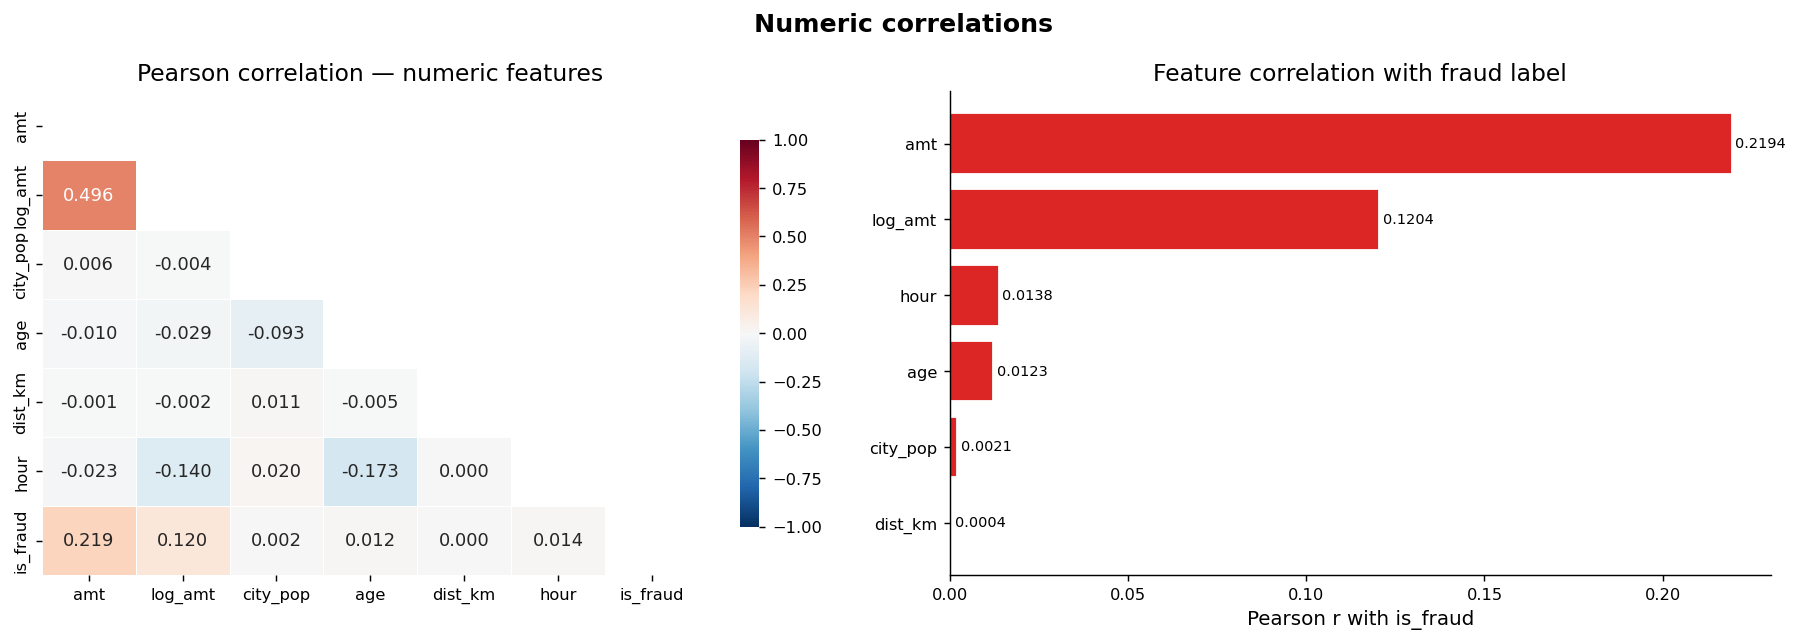

In [10]:
num_cols = ["amt", "log_amt", "city_pop", "age", "dist_km", "hour", "is_fraud"]
corr = train[num_cols].corr()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Lower-triangle heatmap
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, ax=axes[0], annot=True, fmt=".3f",
            cmap="RdBu_r", center=0, vmin=-1, vmax=1,
            linewidths=0.5, linecolor="white",
            cbar_kws={"shrink": 0.8})
axes[0].set_title("Pearson correlation — numeric features")

# Bar chart: correlation with is_fraud
fraud_corr = corr["is_fraud"].drop("is_fraud").sort_values()
bar_colors = [FRAUD if v > 0 else LEGIT for v in fraud_corr]
axes[1].barh(range(len(fraud_corr)), fraud_corr.values, color=bar_colors, edgecolor="white")
axes[1].set_yticks(range(len(fraud_corr)))
axes[1].set_yticklabels(fraud_corr.index)
axes[1].axvline(0, color=NEUTRAL, lw=1)
axes[1].set_xlabel("Pearson r with is_fraud")
axes[1].set_title("Feature correlation with fraud label")
for i, v in enumerate(fraud_corr.values):
    ha = "left" if v >= 0 else "right"
    axes[1].text(v + (0.001 if v >= 0 else -0.001), i,
                 f"{v:.4f}", va="center", ha=ha, fontsize=8)

plt.suptitle("Numeric correlations", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()